<a href="https://colab.research.google.com/github/swayambel/orbital-integrator-stability-checker/blob/main/orbital_integrators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Symplectic vs Non-Symplectic Integrators in Orbital Dynamics

This project investigates the behavior of symplectic and non-symplectic numerical integrators when applied to the gravitational two-body problem.

The study compares the long-term stability of the following methods:

• Heun Method (Improved Euler)  
• Runge–Kutta 4 (RK4)  
• Velocity Verlet (Symplectic)

The objective is to analyze how different integrators affect orbital stability, energy conservation, and radius drift during long simulations.

## 1. Introduction

Numerical integration methods are widely used to simulate dynamical systems in physics. When modeling orbital motion, the choice of integrator can significantly affect the long-term stability of the simulation.

Standard methods such as Runge–Kutta minimize local truncation error but do not preserve the geometric structure of Hamiltonian systems. As a result, they may introduce gradual energy drift during long simulations.

Symplectic integrators, on the other hand, are designed to preserve the phase-space structure of Hamiltonian systems. This often leads to improved long-term stability even when the local error per timestep is larger.

In this project, we compare symplectic and non-symplectic integrators using the classical two-body gravitational problem.

## 2. Two-Body Gravitational Model

The motion of a body under the influence of gravity is governed by Newton's law of gravitation:

d²r/dt² = −GM r / |r|³

where:

• G is the gravitational constant  
• M is the central mass  
• r is the position vector  

For simplicity, the gravitational parameter is normalized:

GM = 1

The initial conditions correspond to a circular orbit:

Position: (1, 0)  
Velocity: (0, 1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Physics functions

In [ ]:
GM = 1.0


def derivatives(state):

    x, y, vx, vy = state

    r = np.sqrt(x**2 + y**2)

    ax = -GM * x / r**3
    ay = -GM * y / r**3

    return np.array([vx, vy, ax, ay])

### Energy function

In [ ]:
def specific_energy(state):

    x, y, vx, vy = state

    r = np.sqrt(x**2 + y**2)
    v2 = vx**2 + vy**2

    return 0.5*v2 - GM/r

### Radius function

In [ ]:
def specific_energy(state):

    x, y, vx, vy = state

    r = np.sqrt(x**2 + y**2)
    v2 = vx**2 + vy**2

    return 0.5*v2 - GM/r

### Initial state testing

In [ ]:
state = np.array([1.0,0.0,0.0,1.0])

print("Derivatives:", derivatives(state))

Derivatives: [ 0.  1. -1. -0.]


## 3. Runge–Kutta 4 (RK4)

The Runge–Kutta 4 method is a fourth-order numerical integrator widely used for solving ordinary differential equations.

It improves accuracy by evaluating the derivative at four intermediate points within each timestep and combining them in a weighted average.

Although RK4 has very small local truncation error, it is **not a symplectic method**. As a result, long-term simulations of Hamiltonian systems may exhibit gradual energy drift.

In [ ]:
def rk4_step(state, dt):

    k1 = derivatives(state)
    k2 = derivatives(state + 0.5 * dt * k1)
    k3 = derivatives(state + 0.5 * dt * k2)
    k4 = derivatives(state + dt * k3)

    return state + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

### Simulation Parameters

In [ ]:
dt = 0.01
steps = 5000

### RK4 Simluation

In [ ]:
state = np.array([1.0,0.0,0.0,1.0])

trajectory_rk4 = []

for _ in range(steps):

    trajectory_rk4.append(state[:2])

    state = rk4_step(state, dt)

trajectory_rk4 = np.array(trajectory_rk4)

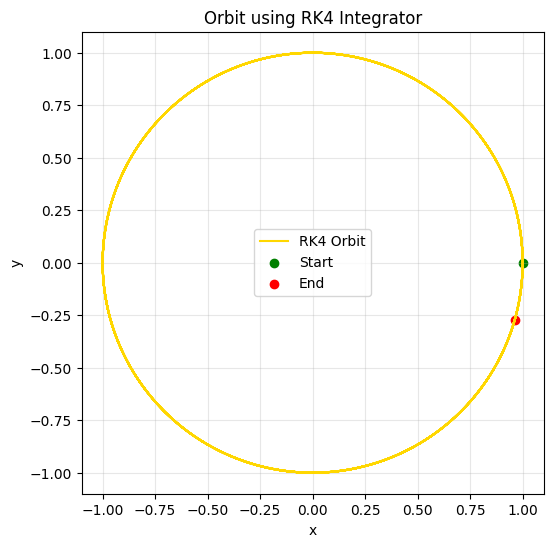

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(
    trajectory_rk4[:,0],
    trajectory_rk4[:,1],
    color="gold",
    label="RK4 Orbit"
)

plt.scatter(trajectory_rk4[0,0],trajectory_rk4[0,1],
            color="green",label="Start")

plt.scatter(trajectory_rk4[-1,0],trajectory_rk4[-1,1],
            color="red",label="End")

plt.gca().set_aspect("equal")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Orbit using RK4 Integrator")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The RK4 integrator produces a nearly perfect circular orbit for the chosen timestep. The start and end points of the trajectory are extremely close, indicating minimal numerical drift during the simulation.RK4 achieves high accuracy by evaluating derivatives multiple times within each timestep. This reduces local truncation error and results in stable short-term simulations.However, despite its accuracy, RK4 does not preserve the Hamiltonian structure of the system. Over very long simulations, small energy drift may still occur.

## 4. Heun Integrator (Improved Euler)

The Heun method is a second-order predictor–corrector integrator that improves upon the basic Euler method.

The method first predicts the next state using a simple Euler step and then corrects this estimate by averaging the derivative at the beginning and end of the timestep.

Although more accurate than Euler, Heun is still a **non-symplectic integrator**. Therefore, small numerical errors may accumulate over long simulations of Hamiltonian systems such as orbital motion.

In [ ]:
def heun_step(state, dt):

    k1 = derivatives(state)

    predictor = state + dt * k1

    k2 = derivatives(predictor)

    return state + 0.5 * dt * (k1 + k2)

### Heun Simulation

In [ ]:
state = np.array([1.0,0.0,0.0,1.0])

trajectory_heun = []

for _ in range(steps):

    trajectory_heun.append(state[:2])

    state = heun_step(state, dt)

trajectory_heun = np.array(trajectory_heun)

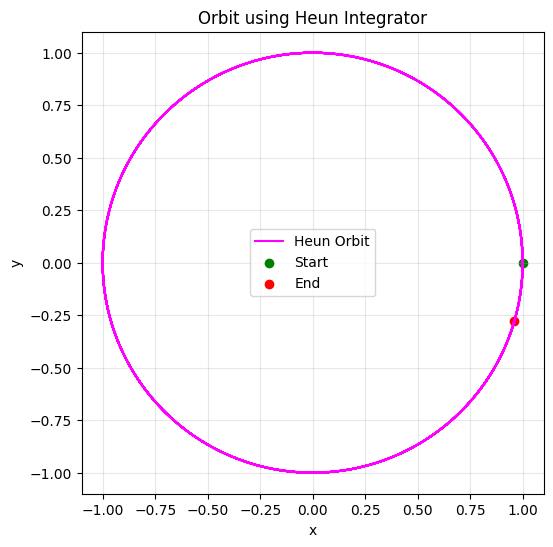

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(
    trajectory_heun[:,0],
    trajectory_heun[:,1],
    color="magenta",
    label="Heun Orbit"
)

plt.scatter(
    trajectory_heun[0,0],
    trajectory_heun[0,1],
    color="green",
    label="Start"
)

plt.scatter(
    trajectory_heun[-1,0],
    trajectory_heun[-1,1],
    color="red",
    label="End"
)

plt.gca().set_aspect("equal")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Orbit using Heun Integrator")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The Heun integrator produces an orbit that remains approximately circular for the duration of the simulation. Compared with the Euler method, the trajectory is significantly more stable because the Heun method averages the derivative at two points within the timestep. However, a small deviation between the start and end points is still visible, indicating the presence of numerical error accumulation over time. Although the method improves accuracy relative to first-order schemes, it does not preserve the Hamiltonian structure of the gravitational system, meaning long-term simulations may still exhibit energy drift.

## 5. Velocity Verlet Integrator

The Velocity Verlet method is a second-order symplectic integrator commonly used in molecular dynamics and orbital simulations.

Unlike standard Runge–Kutta methods, symplectic integrators preserve the geometric structure of Hamiltonian systems. This property helps maintain long-term stability in simulations of conservative systems such as gravitational motion.

The Velocity Verlet algorithm updates position and velocity using both the current and updated accelerations, allowing the method to maintain bounded energy oscillations over long simulations.

### Acceleration Function

In [ ]:
def acceleration(x, y):

    r = np.sqrt(x**2 + y**2)

    ax = -GM * x / r**3
    ay = -GM * y / r**3

    return ax, ay

### Velocity Verlet Step Function

In [ ]:
def velocity_verlet_step(state, dt):

    x, y, vx, vy = state

    ax, ay = acceleration(x, y)

    # update position
    x_new = x + vx*dt + 0.5*ax*dt**2
    y_new = y + vy*dt + 0.5*ay*dt**2

    ax_new, ay_new = acceleration(x_new, y_new)

    # update velocity
    vx_new = vx + 0.5*(ax + ax_new)*dt
    vy_new = vy + 0.5*(ay + ay_new)*dt

    return np.array([x_new, y_new, vx_new, vy_new])

### Velocity Verlet Simulation

In [ ]:
state = np.array([1.0,0.0,0.0,1.0])

trajectory_verlet = []

for _ in range(steps):

    trajectory_verlet.append(state[:2])

    state = velocity_verlet_step(state, dt)

trajectory_verlet = np.array(trajectory_verlet)

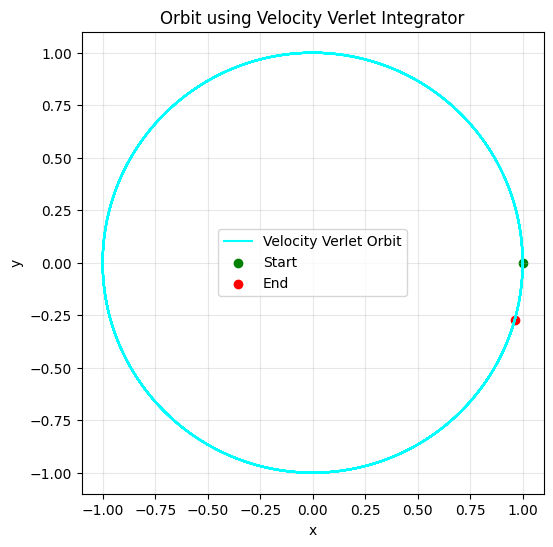

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(
    trajectory_verlet[:,0],
    trajectory_verlet[:,1],
    color="cyan",
    label="Velocity Verlet Orbit"
)

plt.scatter(
    trajectory_verlet[0,0],
    trajectory_verlet[0,1],
    color="green",
    label="Start"
)

plt.scatter(
    trajectory_verlet[-1,0],
    trajectory_verlet[-1,1],
    color="red",
    label="End"
)

plt.gca().set_aspect("equal")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Orbit using Velocity Verlet Integrator")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The Velocity Verlet integrator produces a highly stable circular orbit for the gravitational system. Unlike standard Runge–Kutta methods, Velocity Verlet is a symplectic integrator, meaning it preserves the Hamiltonian structure of the system. This property allows the integrator to maintain long-term stability even when the timestep is relatively large. In orbital simulations, symplectic methods typically produce bounded oscillations in conserved quantities such as energy rather than the gradual drift seen in non-symplectic methods.

## 6. Leapfrog Integrator

The Leapfrog method is a symplectic integrator commonly used in simulations of gravitational and Hamiltonian systems.

In this method, position and velocity are updated at staggered time intervals. Velocity is first updated by half a timestep, after which position is updated using this intermediate velocity.

Because Leapfrog preserves the Hamiltonian structure of the system, it maintains long-term stability in orbital simulations and prevents artificial energy drift.

In [ ]:
def leapfrog_step(state, dt):

    x, y, vx, vy = state

    ax, ay = acceleration(x, y)

    # half-step velocity
    vx_half = vx + 0.5 * ax * dt
    vy_half = vy + 0.5 * ay * dt

    # position update
    x_new = x + vx_half * dt
    y_new = y + vy_half * dt

    # acceleration at new position
    ax_new, ay_new = acceleration(x_new, y_new)

    # complete velocity update
    vx_new = vx_half + 0.5 * ax_new * dt
    vy_new = vy_half + 0.5 * ay_new * dt

    return np.array([x_new, y_new, vx_new, vy_new])

### Leapfrog Simulation

In [ ]:
state = np.array([1.0,0.0,0.0,1.0])

trajectory_leapfrog = []

for _ in range(steps):

    trajectory_leapfrog.append(state[:2])

    state = leapfrog_step(state, dt)

trajectory_leapfrog = np.array(trajectory_leapfrog)

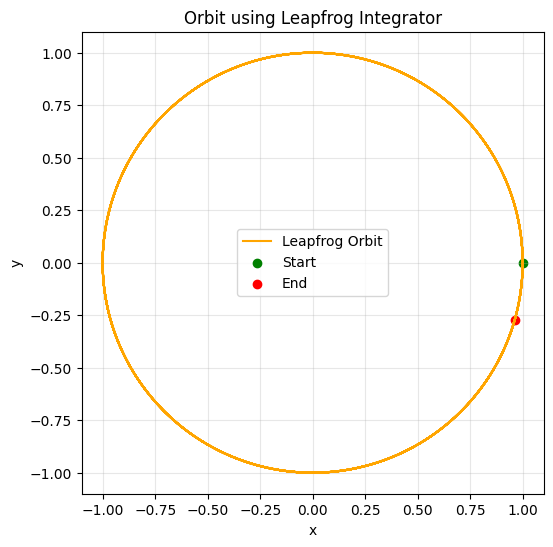

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(
    trajectory_leapfrog[:,0],
    trajectory_leapfrog[:,1],
    color="orange",
    label="Leapfrog Orbit"
)

plt.scatter(
    trajectory_leapfrog[0,0],
    trajectory_leapfrog[0,1],
    color="green",
    label="Start"
)

plt.scatter(
    trajectory_leapfrog[-1,0],
    trajectory_leapfrog[-1,1],
    color="red",
    label="End"
)

plt.gca().set_aspect("equal")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Orbit using Leapfrog Integrator")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The Leapfrog integrator produces a stable circular orbit similar to the Velocity Verlet method. Because Leapfrog is a symplectic integrator, it preserves the Hamiltonian structure of the gravitational system and maintains long-term stability in orbital simulations. The orbit remains nearly circular throughout the simulation, and the small displacement between the start and end points reflects only minor phase error accumulated over multiple orbital periods.

## 7. Orbit Comparison

After implementing the four numerical integrators, their orbital trajectories can now be compared directly.

The goal of this comparison is to visually inspect how each integrator reproduces the circular orbit under identical timestep and initial conditions.

Although the orbit plots may appear similar for sufficiently small timesteps, subtle numerical differences still exist. These differences become more visible when analyzing conserved quantities such as total energy and orbital radius over long simulations.

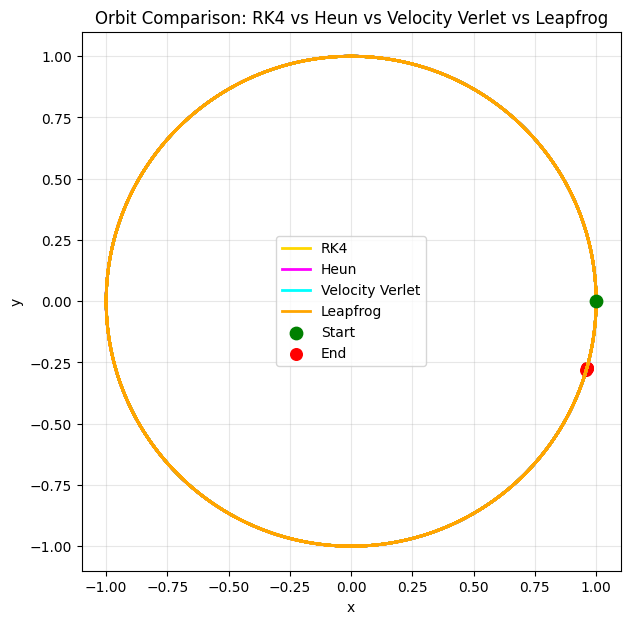

In [ ]:
plt.figure(figsize=(7,7))

# RK4
plt.plot(
    trajectory_rk4[:,0],
    trajectory_rk4[:,1],
    color="gold",
    linewidth=2,
    label="RK4"
)

# Heun
plt.plot(
    trajectory_heun[:,0],
    trajectory_heun[:,1],
    color="magenta",
    linewidth=2,
    label="Heun"
)

# Velocity Verlet
plt.plot(
    trajectory_verlet[:,0],
    trajectory_verlet[:,1],
    color="cyan",
    linewidth=2,
    label="Velocity Verlet"
)

# Leapfrog
plt.plot(
    trajectory_leapfrog[:,0],
    trajectory_leapfrog[:,1],
    color="orange",
    linewidth=2,
    label="Leapfrog"
)

# Start point
plt.scatter(
    1,0,
    color="green",
    s=80,
    label="Start",
    zorder=5
)

# End points
plt.scatter(
    trajectory_rk4[-1,0], trajectory_rk4[-1,1],
    color="red", s=70
)

plt.scatter(
    trajectory_heun[-1,0], trajectory_heun[-1,1],
    color="red", s=70
)

plt.scatter(
    trajectory_verlet[-1,0], trajectory_verlet[-1,1],
    color="red", s=70
)

plt.scatter(
    trajectory_leapfrog[-1,0], trajectory_leapfrog[-1,1],
    color="red", s=70,
    label="End"
)

plt.gca().set_aspect("equal")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Orbit Comparison: RK4 vs Heun vs Velocity Verlet vs Leapfrog")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

### Interpretation

All four integrators produce nearly identical circular orbits under the chosen timestep. This occurs because the timestep is sufficiently small for each method to approximate the true solution accurately. As a result, the geometric structure of the orbit appears stable for all integrators. However, orbit geometry alone does not fully reveal numerical differences between integrators. More detailed diagnostics such as energy drift and radius stability are required to evaluate long-term numerical behavior.

## 8. Energy Drift Analysis

For a gravitational two-body system, the total mechanical energy should remain constant over time.

The specific mechanical energy is defined as:

E = v²/2 − GM/r

where v is the velocity magnitude and r is the distance from the central body.

If a numerical integrator perfectly preserved the physics of the system, the energy would remain constant. In practice, numerical integration introduces truncation errors that cause small deviations.

By tracking the energy over time we can evaluate how well different integrators preserve the physical invariants of the system.